In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2_epos import Hamiltonian, Lattice
from scripts.self_consistency_v2_epos import *
from scripts.utils import is_hermitian

In [2]:
X, Y = 10,50
lattice = Lattice(X, Y)

t = 1
mu = -1.8 * t * np.ones(lattice.X)

U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, U=None, V_prime=None, V=V, F_init=[0.1, -0.1, 0.1j, -0.1j])

In [4]:
print(is_hermitian(H.matrix))
print(is_hermitian(H.build_Hk(0)))
print(is_hermitian(H.build_Hk(PI/2)))

True
True
True


In [5]:
bdg_self_consistency(H, maxiter=100, atol=1e-3, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 7.40969459794779e-17
Relative error: 7.409694597947789e-05
Average_old: 0j
Average_new: (5.820810413531552e-18+0j)
F_xplus:
Absolute error: 0.14778282060802697
Relative error: 1.477828206065491
Average_old: (0.09999999999999999+0j)
Average_new: (0.05110699874601438+0j)
F_xmin:
Absolute error: 0.14778282060802694
Relative error: 1.4778282060950476
Average_old: (-0.09999999999999999+0j)
Average_new: (-0.05110699874601439+0j)
F_yplus:
Absolute error: 0.10389507004565941
Relative error: 1.038950700456594
Average_old: 0.1j
Average_new: (8.81049790416033e-18+0.06731747037734484j)
F_ymin:
Absolute error: 0.10389507004565941
Relative error: 1.038950700456594
Average_old: -0.1j
Average_new: (8.81049790416033e-18-0.06731747037734484j)
Fuu_xplus:
Absolute error: 1.7034927174578982e-17
Relative error: 1.7034927174578978e-05
Average_old: 0j
Average_new: (-5.058597324468339e-19+0j)
Fuu_xmin:
Absolute error: 1.0638052869790288e-17
Relative error: 1.0638052869790288e-0

In [6]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [7]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = F_xplus
Fx_m[1:]  = F_xmin

Fuux_p = np.zeros(Nx, dtype=complex)
Fuux_m = np.zeros(Nx, dtype=complex)
Fuux_p[:-1] = Fuu_xplus
Fuux_m[1:]  = Fuu_xmin

Fddx_p = np.zeros(Nx, dtype=complex)
Fddx_m = np.zeros(Nx, dtype=complex)
Fddx_p[:-1] = Fdd_xplus
Fddx_m[1:]  = Fdd_xmin

print(np.mean(F0))
print(np.mean(Fx_p - Fx_m)/2)
print(np.mean(F_yplus - F_ymin)/2)
print(np.mean(Fx_p + Fx_m - F_yplus - F_ymin)/4)
print(np.mean(Fx_p + Fx_m + F_yplus + F_ymin)/4)
# U=5.2 : (0.027423485852989458+0j)
# U = 2: (0.017987400064643444+0j) 
# Rest are edges but why not extended s

(-1.4659429811540724e-17+0j)
(2.5635374052213664e-14+0j)
0.02276648509710252j
(4.1530448920351974e-18+0j)
(-7.969013022710545e-18+0j)


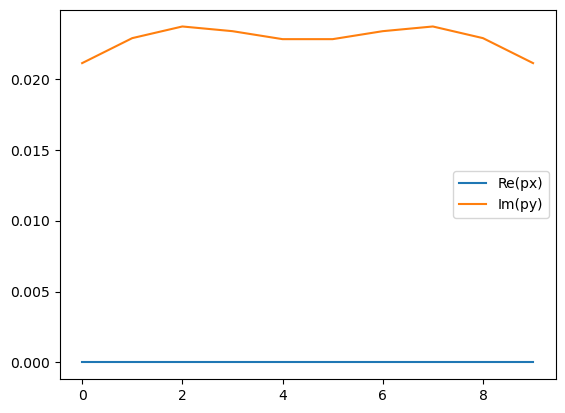

In [8]:
plt.plot(np.real(Fx_p - Fx_m)/2, label='Re(px)')
# plt.plot(np.real(Fddx_p - Fddx_m)/2, label='Re(px) down-down')
# plt.plot(np.real(Fuux_p - Fuux_m)/2, label='Re(px) up-up')
# plt.plot(np.imag(Fdd_yplus - Fdd_ymin)/2, label='Im(py) down-down')
# plt.plot(np.imag(Fuu_yplus - Fuu_ymin)/2, label='Im(py) up-up')

plt.plot(np.imag(F_yplus - F_ymin)/2, label='Im(py)')
# plt.plot(np.abs(F0), label='on-site')
# plt.plot(np.real(Fx_p + Fx_m - F_yplus - F_ymin)/4, label='d-wave')
# plt.plot(np.real(Fx_p + Fx_m + F_yplus + F_ymin)/4, label='extended-s')
plt.legend()